# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

## Frequency analysis

In [4]:
idata_frequency = az.from_netcdf(RESULTS_DIR / "idata_frequency.nc")
idata_frequency_bsl = az.from_netcdf(RESULTS_DIR / "idata_frequency_baseline.nc")
idata_frequency

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [5]:
print("Freq:")
display(az.summary(idata_frequency, var_names=["~mu", "~1|rat"]))
print("Freq baseline:")
display(az.summary(idata_frequency_bsl, var_names=["~mu", "~1|rat"]))

Freq:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.001,0.000,0.001,0.002,0.0,0.0,3920.0,2797.0,1.00
Intercept,0.004,0.001,0.002,0.006,0.0,0.0,1646.0,1403.0,1.00
gtyp[fa/fa],-0.002,0.001,-0.004,0.000,0.0,0.0,1702.0,2127.0,1.00
age[Young],-0.002,0.002,-0.005,0.001,0.0,0.0,1961.0,2300.0,1.00
sex[M],0.001,0.002,-0.003,0.004,0.0,0.0,1998.0,1972.0,1.00
"gtyp:age[fa/fa, Young]",0.003,0.002,-0.001,0.008,0.0,0.0,1992.0,2189.0,1.00
"gtyp:sex[fa/fa, M]",-0.007,0.002,-0.011,-0.003,0.0,0.0,2082.0,2117.0,1.00
1|rat_sigma,0.002,0.000,0.001,0.003,0.0,0.0,1205.0,1998.0,1.01


Freq baseline:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.002,0.000,0.002,0.002,0.0,0.0,3958.0,2789.0,1.0
Intercept,0.028,0.001,0.025,0.030,0.0,0.0,1844.0,2097.0,1.0
gtyp[fa/fa],-0.004,0.002,-0.008,0.000,0.0,0.0,1955.0,2284.0,1.0
age[Young],-0.003,0.003,-0.008,0.003,0.0,0.0,2545.0,2471.0,1.0
sex[M],0.001,0.003,-0.004,0.006,0.0,0.0,2566.0,2530.0,1.0
"gtyp:age[fa/fa, Young]",0.006,0.004,-0.000,0.013,0.0,0.0,2413.0,2365.0,1.0
"gtyp:sex[fa/fa, M]",-0.001,0.004,-0.008,0.005,0.0,0.0,2416.0,2529.0,1.0
1|rat_sigma,0.004,0.001,0.002,0.005,0.0,0.0,1502.0,1941.0,1.0


# Compute group values

In [7]:
t_groups_change, t_groups_bsl = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_frequency, idata_frequency_bsl)
)

In [8]:
ts_change, ts_vehicle = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_change = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))

Change sign probabilities:


{'fa/fa adult M': 0.003,
 'fa/fa young M': 0.01525,
 'fa/+ adult M': 0.99575,
 'fa/+ young M': 0.9945,
 'fa/fa adult F': 0.97475,
 'fa/fa young F': 0.99925,
 'fa/+ adult F': 1.0,
 'fa/+ young F': 0.9175}

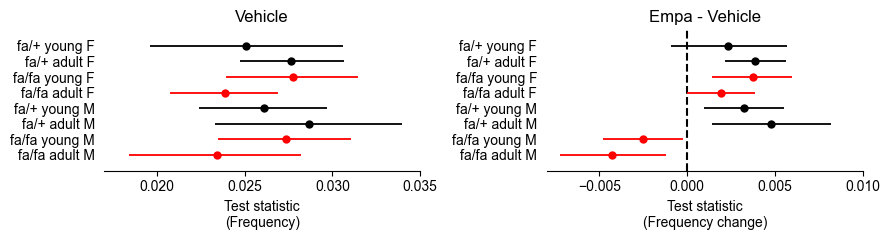

In [11]:
f, axes = plt.subplots(1, 2, figsize=(9, 2.5))
axes[1] = forestplot_oz(axes[1], ts_change);
axes[1].set_title("Empa - Vehicle");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('Test statistic\n(Frequency change)')
axes[0].set_xlabel('Test statistic\n(Frequency)')

axes[0].set_xlim(0.017, 0.035)
axes[1].set_xlim(-0.008, 0.01)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_freq_groups.pdf", bbox_inches="tight")

## TS representing the difference between fa/fa and fa/+

In [12]:
ts_change, ts_vehicle = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        # "M": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2,
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],    
        # "F": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2
        "adult": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"])/2,
        "young": (t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2
       
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'M adult': 0.0,
 'M young': 0.00075,
 'F adult': 0.061,
 'F young': 0.7555,
 'adult': 0.0005,
 'young': 0.06775}


Vehicle sign probabilities:


{'M adult': 0.07725,
 'M young': 0.695,
 'F adult': 0.0355,
 'F young': 0.7915,
 'adult': 0.0315,
 'young': 0.8065}

[]

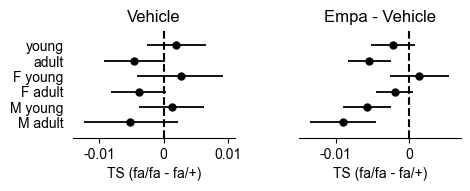

In [15]:
f, axes = plt.subplots(1, 2, figsize=(5, 1.4))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empa - Vehicle')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (fa/fa - fa/+)')


axes[0].set_xlim(-0.014,0.011)
axes[1].set_xlim(-0.015,0.007)
axes[1].set_xticks([-0.01, 0], [-0.01, 0])
axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])


axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_freq_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## TS representing the difference between young and adult

In [16]:
ts_change, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "fa/fa": (t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"])/2,
        # "fa/+": (t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"] + t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_age = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.91075, 'fa/+': 0.18275}


Vehicle sign probabilities:


{'fa/fa': 0.96, 'fa/+': 0.17225}

[]

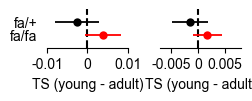

In [17]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (young - adult)')
    
axes[0].set_xlim(-0.01,0.01)
axes[1].set_xlim(-0.007, 0.008)

axes[1].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])

axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_freq_CompareAgeForGtypsSexes.pdf", bbox_inches="tight")

## TS representing the difference between males and females

In [18]:
ts_change, ts_vehicle = (
    {
        "fa/fa":  t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        # "young fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:female:young"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "young fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_sex = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.00025, 'fa/+': 0.70125}


Vehicle sign probabilities:


{'fa/fa': 0.4305, 'fa/+': 0.64025}

[]

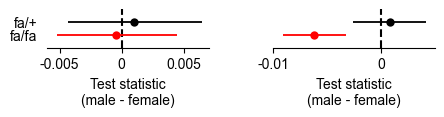

In [20]:
f, axes = plt.subplots(1, 2, figsize=(5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(male - female)')
    
axes[0].set_xlim(-0.006,0.007)
axes[1].set_xlim(-0.01, 0.005)
axes[0].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
axes[1].set_xticks([-0.01, 0], [-0.01, 0])
axes[1].set_yticks([],[])

# f.savefig(PLOT_DIR / "ts_freq_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [21]:
sp_all = pd.concat(objs=(sign_probabilities_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('freq',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/freq.csv')
sp_all

change change_signif  vehicle vehicle_signif
contrast      group                                                       
freq          fa/fa adult M  0.00300             *      NaN            NaN
              fa/fa young M  0.01525             *      NaN            NaN
              fa/+ adult M   0.99575             *      NaN            NaN
              fa/+ young M   0.99450             *      NaN            NaN
              fa/fa adult F  0.97475                    NaN            NaN
              fa/fa young F  0.99925             *      NaN            NaN
              fa/+ adult F   1.00000             *      NaN            NaN
              fa/+ young F   0.91750                    NaN            NaN
fa/fa - fa/+  M adult        0.00000             *  0.07725               
              M young        0.00075             *  0.69500               
              F adult        0.06100                0.03550               
              F young        0.75550                0.79150               
              adult          0.00050             *  0.03150               
              young          0.06775                0.80650               
young - adult fa/fa          0.91075                0.96000               
              fa/+           0.18275                0.17225               
male - female fa/fa          0.00025             *  0.43050               
              fa/+           0.70125                0.64025